# Figure 2.2/2.3 — Functional consequences of drift for downstream readout

Two-panel combined figure:

| Panel | Content |
|-------|---------|
| **A** | Static readout degradation over days at the canonical operating point (E = 1.5, σ = 0.02) |
| **B** | Functional memory lifespan across the full E × σ parameter grid |

In [6]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, os.getcwd())
from model import ModelParams, get_or_run, compute_readout_accuracy, run_decoder_sweep
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW, LINEWIDTH_IN

NOTEBOOK_DIR = os.path.abspath('')
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, 'saved_figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

## Parameters

In [7]:
# ── Panel A: canonical readout degradation ────────────────────────────────────
E_A       = 1.5
vol_A     = 0.02
seeds_A   = [0, 1, 2, 3, 4]

# ── Panel B: lifespan heatmap ─────────────────────────────────────────────────
E_values       = [0.0, 0.5, 1.0, 1.5, 2.0]
vol_std_values = [0.0, 0.01, 0.02, 0.04, 0.06]
seeds_B        = [0, 1, 2]
ACC_THRESHOLD  = 0.75

In [8]:
# ── Panel A data ──────────────────────────────────────────────────────────────
all_acc = []
for seed in seeds_A:
    p    = ModelParams(E=E_A, vol_std=vol_A, seed=seed)
    name = f'pca3d_E{E_A}_vol{vol_A}_s{seed}'
    res  = get_or_run(p, name)
    if res['params'] != p:
        res = get_or_run(p, name, force=True)
    acc, _ = compute_readout_accuracy(res)
    all_acc.append(acc)

all_acc  = np.array(all_acc)
mean_acc = all_acc.mean(axis=0)
sem_acc  = all_acc.std(axis=0) / np.sqrt(len(seeds_A))
days_A   = list(range(1, ModelParams().Nevent + 1))
print(f'[A] Mean accuracy by day: {np.round(mean_acc, 3)}')

Running simulation (seed=0, E=1.5, vol_std=0.02) ...
Running simulation (seed=1, E=1.5, vol_std=0.02) ...
Running simulation (seed=2, E=1.5, vol_std=0.02) ...
Running simulation (seed=3, E=1.5, vol_std=0.02) ...
Running simulation (seed=4, E=1.5, vol_std=0.02) ...
[A] Mean accuracy by day: [0.784 0.692 0.672 0.667]


In [9]:
# ── Panel B data ──────────────────────────────────────────────────────────────
sweep = run_decoder_sweep(
    E_values       = E_values,
    vol_std_values = vol_std_values,
    seeds          = seeds_B,
    name           = 'fig2_3_1_decoder_sweep',
)

acc_mean = sweep['accuracy'].mean(axis=2)   # (nE, nvol, Nevent)
nE_      = len(sweep['E_values'])
nvol_    = len(sweep['vol_std_values'])
Nevent_  = acc_mean.shape[-1]

lifespan = np.zeros((nE_, nvol_))
for i in range(nE_):
    for j in range(nvol_):
        count = 0
        for d in range(Nevent_):
            if acc_mean[i, j, d] > ACC_THRESHOLD:
                count += 1
            else:
                break
        lifespan[i, j] = count

print(f'[B] Lifespan matrix (E rows × vol_std cols):')
print(np.round(lifespan, 0).astype(int))

  [75/75] E=2.00  vol_std=0.0600  seed=2
[B] Lifespan matrix (E rows × vol_std cols):
[[4 4 2 4 4]
 [4 4 2 4 4]
 [4 4 1 4 4]
 [4 3 1 2 4]
 [1 1 1 1 4]]


Figure saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig2_2_3_combined.pdf


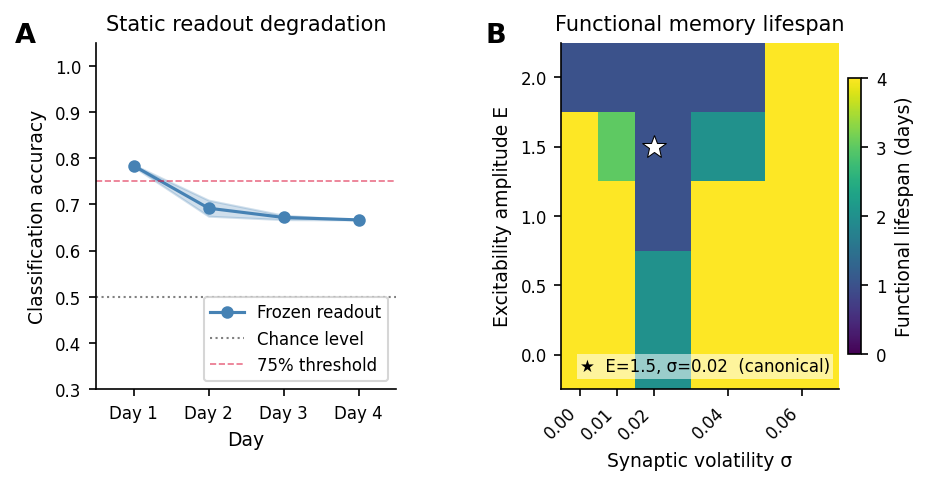

In [11]:
apply_style()

# A4 linewidth at scale=1: LINEWIDTH_IN ≈ 6.30 in.  Height 3.5 in gives a readable two-panel layout.
fig = plt.figure(figsize=(LINEWIDTH_IN, 3.5))
gs  = gridspec.GridSpec(1, 2, figure=fig,
                        left=0.12, right=0.93, top=0.88, bottom=0.22,
                        wspace=0.55)

ax_A = fig.add_subplot(gs[0])
ax_B = fig.add_subplot(gs[1])

def _label(ax, txt, x=-0.20, y=1.06):
    ax.text(x, y, txt, transform=ax.transAxes,
            fontsize=FONT['panel_label'], fontweight='bold', va='top', ha='right')


# ── Panel A — Static readout degradation ─────────────────────────────────────
days_arr = np.array(days_A)

ax_A.fill_between(days_arr, mean_acc - sem_acc, mean_acc + sem_acc,
                  color=COLORS['input'], alpha=0.25)
ax_A.plot(days_arr, mean_acc, color=COLORS['input'], lw=LW['trace'] * 1.5,
          marker='o', markersize=5, label='Frozen readout')
ax_A.axhline(0.5, color=COLORS['neutral'], lw=LW['trace'], ls=':',
             label='Chance level')
ax_A.axhline(ACC_THRESHOLD, color=COLORS['highlight'], lw=0.8, ls='--', alpha=0.6,
             label=f'{ACC_THRESHOLD:.0%} threshold')

ax_A.set_xlim(0.5, len(days_A) + 0.5)
ax_A.set_ylim(0.3, 1.05)
ax_A.set_xticks(days_arr)
ax_A.set_xticklabels([f'Day {d}' for d in days_A])
ax_A.set_xlabel('Day')
ax_A.set_ylabel('Classification accuracy')
ax_A.set_title('Static readout degradation')   # params are in the caption
ax_A.legend(fontsize=FONT['annotation'], loc='lower right')
_label(ax_A, 'A')


# ── Panel B — Lifespan heatmap ────────────────────────────────────────────────
E_arr   = np.array(sweep['E_values'])
vol_arr = np.array(sweep['vol_std_values'])

im = ax_B.pcolormesh(vol_arr, E_arr, lifespan,
                     cmap='viridis', vmin=0, vmax=Nevent_, shading='auto')
cbar = fig.colorbar(im, ax=ax_B, pad=0.03, fraction=0.046)
cbar.set_label('Functional lifespan (days)', fontsize=FONT['axis_label'])
cbar.set_ticks(list(range(Nevent_ + 1)))
cbar.ax.tick_params(labelsize=FONT['colorbar'])

# Canonical marker — no legend box; annotate directly at bottom of axes
ax_B.plot(vol_A, E_A, '*', color='white', markersize=12,
          markeredgecolor='black', markeredgewidth=0.5, zorder=5)
ax_B.text(0.97, 0.04, f'★  E={E_A}, σ={vol_A}  (canonical)',
          transform=ax_B.transAxes, fontsize=FONT['annotation'],
          ha='right', va='bottom',
          bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=1.5))

ax_B.set_xticks(vol_arr)
ax_B.set_yticks(E_arr)
ax_B.set_xticklabels([f'{v:.2f}' for v in vol_arr],
                     rotation=45, ha='right', fontsize=FONT['tick'])
ax_B.set_yticklabels([f'{e:.1f}' for e in E_arr], fontsize=FONT['tick'])
ax_B.set_xlabel('Synaptic volatility σ')
ax_B.set_ylabel('Excitability amplitude E')
ax_B.set_title(f'Functional memory lifespan')
_label(ax_B, 'B')


out_path = os.path.join(FIGURES_DIR, 'fig2_2_3_combined.pdf')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Figure saved -> {out_path}')
plt.show()